In [1]:
#to run on your machine, you'll need to change the directories specified in 
#NeuralDecoder/neuralDecoder/configs/dataset/speech_release_baseline.yaml
#and change "outputDir" specified below

import os
baseDir = 'C:/Users/krishna/Documents/NeuroSpeech/speechBCI-main'
os.chdir(baseDir)
os.makedirs(baseDir+'/derived/rnns', exist_ok=True)

In [ ]:
# Verification that GPU is seen, if not, will use CPU instead which will be slower
# Should list device_type='CPU' and below that 'GPU'
# TF version: 2.10.0

import tensorflow as tf

print("TF version:", tf.__version__)
print("Available devices:")
for d in tf.config.list_physical_devices():
    print(d)

TF version: 2.10.0
Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
import subprocess
import sys

# Build the command as a list
cmd = [
    sys.executable, "-m", "neuralDecoder.main",
    "dataset=speech_release_baseline",
    "model=gru_stack_inputNet",
    "learnRateDecaySteps=10000",
    "nBatchesToTrain=10",
    "learnRateStart=0.02",
    "model.nUnits=1024",
    "model.stack_kwargs.kernel_size=32",
    "outputDir=C:/Users/krishna/Documents/NeuroSpeech/speechBCI-main/derived/rnns/baselineRelease"
]

# Run the command and stream output live
process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

# Print output line by line as it comes
for line in process.stdout:
    print(line, end="")

process.wait()
print(f"Process finished with exit code {process.returncode}")

c:\Users\krishna\AppData\Local\Programs\Python\Python39\lib\site-packages\wandb\apis\public.py:3080: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
2025-11-04 19:45:30.515885: I tensorflow/c/logging.cc:34] Successfully opened dynamic library c:\Users\krishna\AppData\Local\Programs\Python\Python39\lib\site-packages\tensorflow-plugins/directml/directml.d6f03b303ac3c4f2eeb8ca631688c9757b361310.dll
2025-11-04 19:45:30.516858: I tensorflow/c/logging.cc:34] Successfully opened dynamic library dxgi.dll
2025-11-04 19:45:30.528674: I tensorflow/c/logging.cc:34] Successfully opened dynamic library d3d12.dll
2025-11-04 19:45:30.724660: I tensorflow/c/logging.cc:34] DirectML device enumeration: found 1 compatible adapters.
C:\Users\krishna\Documents\NeuroSpeech\spe

dict_keys(['__header__', '__version__', '__globals__', 'logitsSnapshot', 'inputFeaturesSnapshot', 'perBatchData_train', 'perBatchData_val', 'seqIDs'])


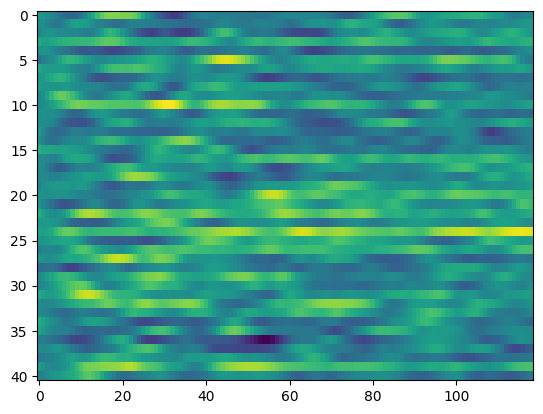

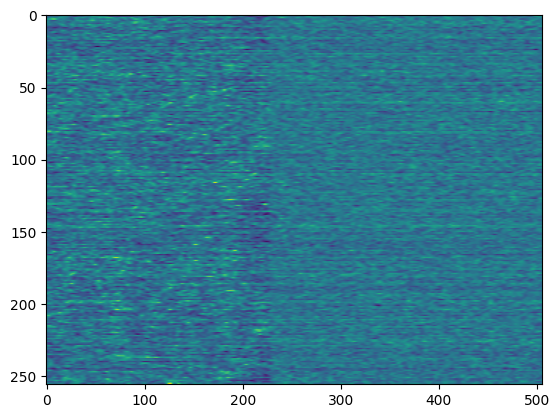

(506, 256)

In [5]:
#we can visualize the logits and the input features here as a sanity check by loading the output snapshot file
import scipy.io
dat = scipy.io.loadmat(baseDir+'/derived/rnns/baselineRelease/outputSnapshot')
print(dat.keys())

dat['logitsSnapshot'].shape
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.imshow(dat['logitsSnapshot'].T, aspect='auto')
plt.show()

plt.figure()
plt.imshow(dat['inputFeaturesSnapshot'].T, aspect='auto')
plt.show()

dat['inputFeaturesSnapshot'].shape